## Import libaries

In [14]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve()))

import numpy as np

from shapely.geometry import MultiPolygon, Point
from shapely.prepared import prep

import matplotlib.pyplot as plt
import geopandas as gpd
import utils.ahn_utils as ahn_utils
import utils.las_utils as las_utils
from config import TILE_DIR, AHN_RAW_DIR, AHN_NPZ_DIR, AHN_GRID_SHP, BBOX_DIR, SETUP_TILECODES

1. Read ground scan

In [15]:
tilecodes = SETUP_TILECODES

input_dir        = TILE_DIR
out_folder_ahn   = AHN_NPZ_DIR
crs              = "EPSG:28992"
ahn_dir          = AHN_RAW_DIR
ahn_grid_path    = AHN_GRID_SHP
output_dir       = AHN_RAW_DIR / "ahn_subsets"
input_subset_dir = AHN_RAW_DIR / "ahn_subsets"

In [16]:
polygons = {}

for tilecode in tilecodes:
    input_file = input_dir / f"{tilecode}.laz"

    try:
        poly = las_utils.build_convex_hull_polygon(input_file)
        polygons[tilecode] = poly
        print(f"Processed {tilecode} successfully.")
    except Exception as e:
        print(f"Failed processing {tilecode}: {e}")

Processed 120300_489300 successfully.
Processed 120300_488900 successfully.


In [17]:
for key, polygon in polygons.items():
    gdf_polygon = gpd.GeoDataFrame(
        {"tilecode": [key]},
        geometry=[polygon],
        crs=crs
    )
    BBOX_DIR.mkdir(parents=True, exist_ok=True)
    gdf_polygon.to_file(BBOX_DIR / f"bbox_{key}.geojson", driver="GeoJSON")

In [18]:
gdf_ahn = gpd.read_file(ahn_grid_path)

for tilecode, poly in polygons.items():

    centroid = poly.centroid
    gdf_point = gpd.GeoDataFrame({"tilecode": [tilecode]}, geometry=[centroid], crs=crs)
    joined = gpd.sjoin(gdf_point, gdf_ahn)
    ahn_codes = joined["GT_AHNSUB"].unique().tolist()

    geometries = list(poly.geoms) if isinstance(poly, MultiPolygon) else [poly]

    for ahn_code in ahn_codes:
        input_ahn = ahn_dir / f"{ahn_code}.LAZ"
        if not input_ahn.exists():
            print(f"Missing AHN tile {ahn_code} for {tilecode} — run notebook 0 first")
            continue

        output_file = output_dir / f"ahn_{tilecode}.laz"

        for geom in geometries:
            try:
                las_utils.crop_laz_with_polygon(
                    input_file=input_ahn,
                    output_file=output_file,
                    polygon=geom
                )
                print(f"Cropped {tilecode} from {ahn_code}")
            except Exception as e:
                print(f"Failed {tilecode}: {e}")

Cropped 120300_489300 from 25EZ1_16
Cropped 120300_488900 from 25EZ1_16


In [19]:
for tilecode, poly in polygons.items():

    subset_ahn_file = input_subset_dir / f"ahn_{tilecode}.laz"

    if not subset_ahn_file.exists():
        print(f"Missing subset file for {tilecode}: {subset_ahn_file}")
        continue

    try:
        npz_file = ahn_utils.process_subset_laz_file(
            subset_ahn_file,
            poly,
            out_folder_ahn,
            resolution=0.1
        )

        print(f"Surface grids saved for {tilecode}: {npz_file}")

    except Exception as e:
        print(f"Failed processing {tilecode}: {e}")

Surface grids saved for 120300_489300: data/output/ahn/ahn_120300_489300.npz
Surface grids saved for 120300_488900: data/output/ahn/ahn_120300_488900.npz


## Optional plotting

In [20]:
surface_ahn_npz_data = np.load(AHN_NPZ_DIR / f"ahn_{SETUP_TILECODES[0]}.npz")

x = surface_ahn_npz_data['x']         # 1D array of x coordinates (grid columns)
y = surface_ahn_npz_data['y']         # 1D array of y coordinates (grid rows)
ground = surface_ahn_npz_data['ground']    # 2D array of ground surface elevations
building = surface_ahn_npz_data['building']  # 2D array of building surface elevations

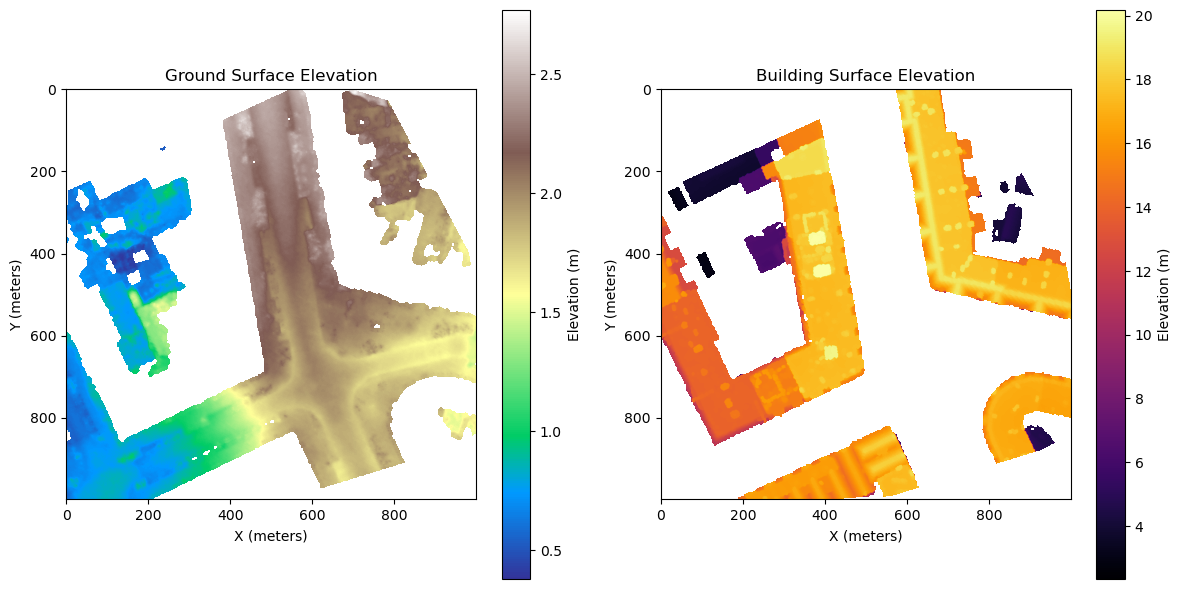

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Ground surface -- the extents are not the actual extent of the polygon
im1 = ax1.imshow(ground,
                 cmap='terrain', origin='upper')
ax1.set_title('Ground Surface Elevation')
ax1.set_xlabel('X (meters)')
ax1.set_ylabel('Y (meters)')
fig.colorbar(im1, ax=ax1, label='Elevation (m)')

# Building surface - the extents are not the actual extent of the polygon
im2 = ax2.imshow(building,
                 cmap='inferno', origin='upper')
ax2.set_title('Building Surface Elevation')
ax2.set_xlabel('X (meters)')
ax2.set_ylabel('Y (meters)')
fig.colorbar(im2, ax=ax2, label='Elevation (m)')

plt.tight_layout()
plt.show()
